In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle 

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler

In [4]:
import pandas as pd

df = pd.read_csv("diabetes.csv")
df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


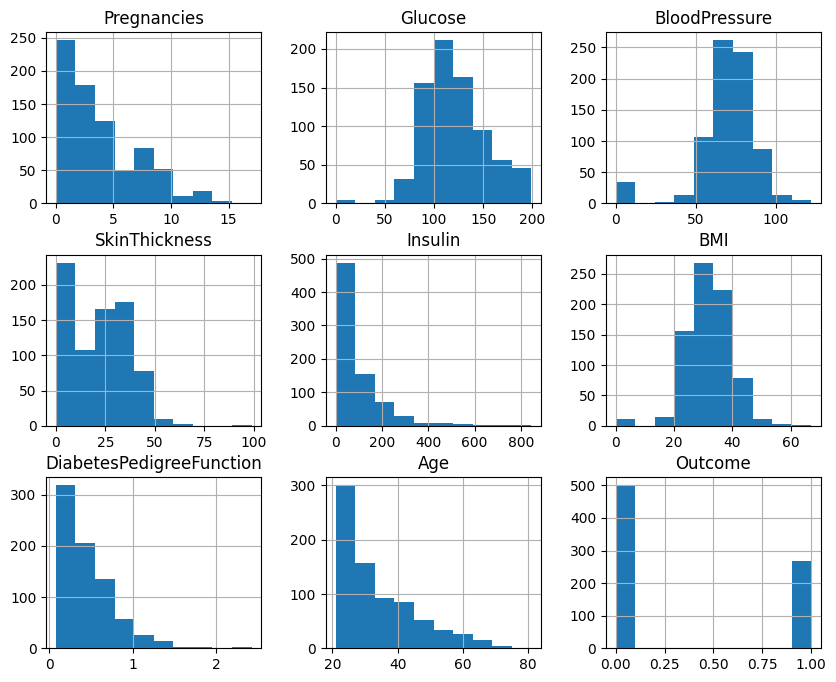

In [21]:
df.hist(figsize=(10,8))
plt.show()

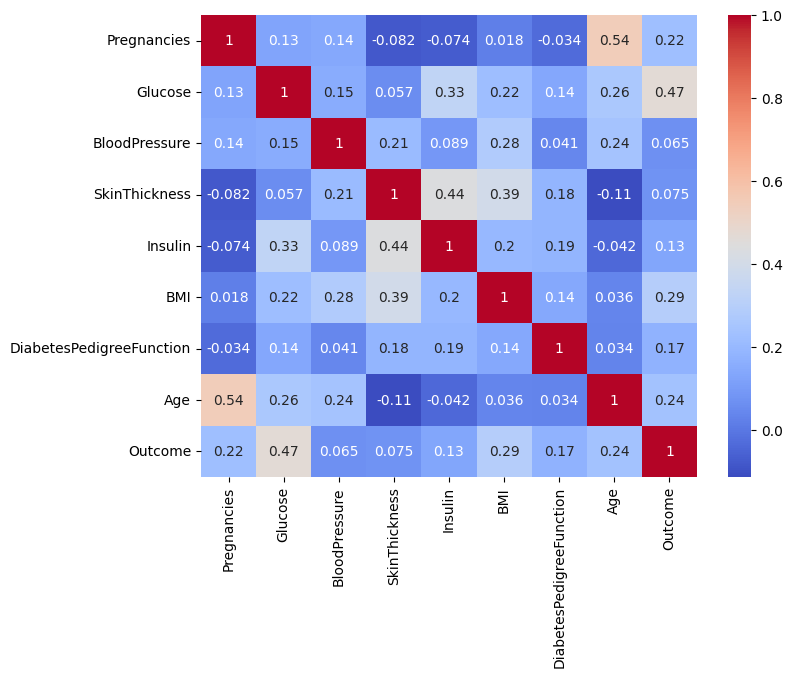

In [22]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

In [23]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [ ]:
# df.fillna(df.mean(), inplace=True)

### Data Preprocessing

The dataset does not contain NaN values. However, several medical features contain 0, which represents missing or invalid measurements. Therefore, these values will be handled before training the model.

In [8]:
columns = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

for column in columns:
    print(f"{column}: {(df[column] == 0).sum()} zero values")

Glucose: 0 zero values
BloodPressure: 0 zero values
SkinThickness: 0 zero values
Insulin: 0 zero values
BMI: 0 zero values


In [9]:
columns = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

for column in columns:
    median = df[column].replace(0, np.nan).median()
    df[column] = df[column].replace(0, median)

In [10]:
for column in columns:
    print(f"{column}: {(df[column] == 0).sum()} zero values")

Glucose: 0 zero values
BloodPressure: 0 zero values
SkinThickness: 0 zero values
Insulin: 0 zero values
BMI: 0 zero values


### Outlier Detection

Box plots are used to identify potential outliers in numerical features before model training.

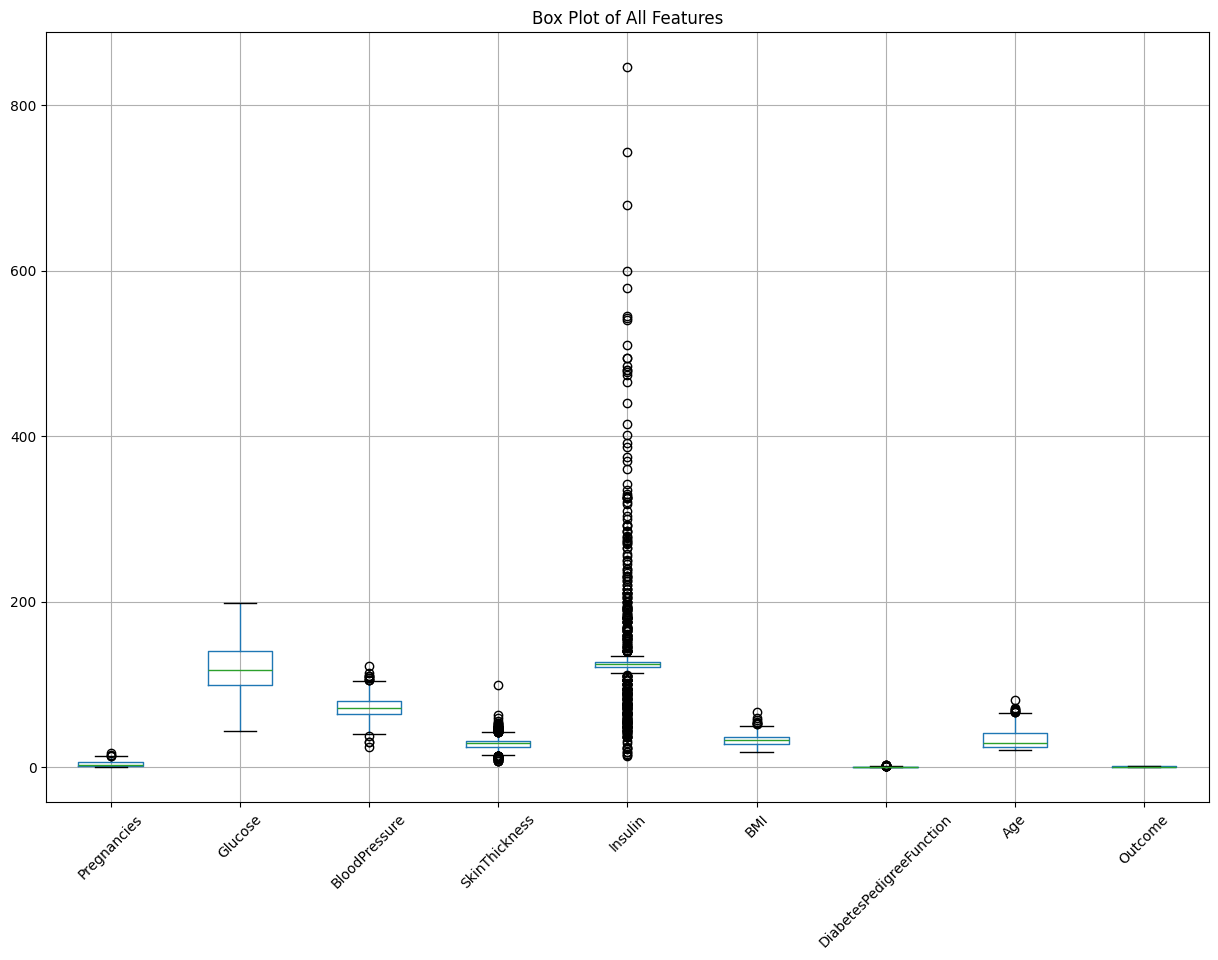

In [11]:
plt.figure(figsize=(15,10))

df.boxplot()

plt.title("Box Plot of All Features")
plt.xticks(rotation=45)

plt.show()

In [18]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [19]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

### Multicollinearity Check using VIF

Variance Inflation Factor (VIF) is used to measure multicollinearity among independent variables. Lower VIF values indicate low correlation between features, while higher values suggest multicollinearity.

In [20]:
vif_data = pd.DataFrame()

vif_data["Feature"] = X.columns

vif_data["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

vif_data

,Feature,VIF
0,Pregnancies,3.273488
1,Glucose,21.723850
2,BloodPressure,31.717477
3,SkinThickness,17.321002
4,Insulin,4.528320
5,BMI,33.678170
6,DiabetesPedigreeFunction,3.153079
7,Age,14.357379


### VIF Interpretation

Variance Inflation Factor (VIF) analysis showed that some features, such as Glucose, BloodPressure, BMI, SkinThickness, and Age, have relatively high VIF values, indicating multicollinearity.

However, these features were retained because they are medically significant predictors of diabetes. Removing them could reduce the predictive ability of the Logistic Regression model.

In [21]:
model = LogisticRegression(max_iter=1000, random_state=42)

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [22]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

In [23]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7532467532467533
              precision    recall  f1-score   support

           0       0.80      0.83      0.81        99
           1       0.67      0.62      0.64        55

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.73       154
weighted avg       0.75      0.75      0.75       154



### Confusion Matrix

A confusion matrix was generated to evaluate the classification performance of the Logistic Regression model by comparing actual and predicted class labels.

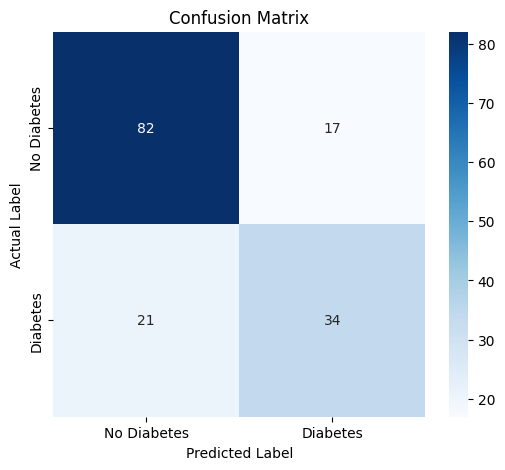

In [24]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Diabetes", "Diabetes"],
    yticklabels=["No Diabetes", "Diabetes"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")

plt.show()

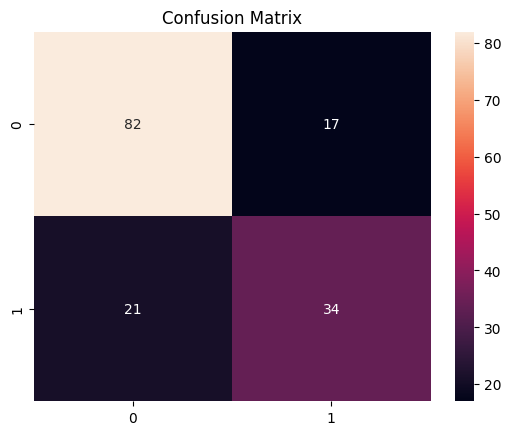

In [25]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

ROC AUC Score: 0.82277318640955


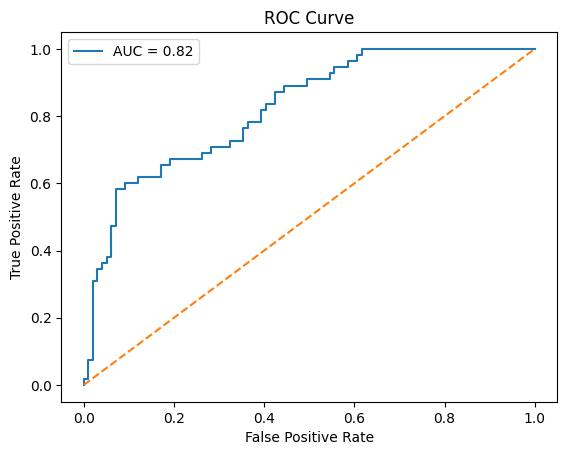

In [26]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

print("ROC AUC Score:", roc_auc)

plt.plot(fpr, tpr, label="AUC = %.2f" % roc_auc)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## Model Saving using Pickle

The trained Logistic Regression model and StandardScaler were saved using Pickle. Saving the model allows it to be reused later for prediction without retraining.

In [28]:
with open("diabetes_model.pkl", "wb") as file:
    pickle.dump(model, file)

In [29]:
with open("scaler.pkl", "wb") as file:
    pickle.dump(scaler, file)

In [32]:
coeff = pd.DataFrame(model.coef_[0], X.columns, columns=['Coefficient'])
print(coeff)

                          Coefficient
Pregnancies                  0.064373
Glucose                      0.034095
BloodPressure               -0.013879
SkinThickness                0.003291
Insulin                     -0.001803
BMI                          0.102607
DiabetesPedigreeFunction     0.626718
Age                          0.037095


#Interview Questions

1. What is the difference between precision and recall?

Answer: Precision and Recall are two important metrics used to evaluate the performance of a classification model, especially when dealing with problems like disease prediction, fraud detection, or spam detection.

Precision tells us how many of the positive predictions made by the model were actually correct. In simple words, when the model predicts that a patient has diabetes, precision tells us how often that prediction is correct.

Recall tells us how many of the actual positive cases the model was able to identify. In other words, out of all the patients who really have diabetes, recall tells us how many the model successfully detected.

If our priority is to avoid giving false alarms, we focus on Precision. If our priority is to make sure we don't miss any actual patients with the disease, we focus on Recall.

2. What is cross-validation, and why is it important in binary classification?

Answer: Cross-validation is a model evaluation technique in which the dataset is divided into multiple parts (called folds). The model is trained and tested multiple times using different combinations of these folds, and the final performance is calculated by averaging the results.

Importance in Binary Classification:
In binary classification problems such as diabetes prediction, spam detection, or fraud detection, cross-validation helps evaluate how well the model will perform on unseen data. It reduces the risk of overfitting, makes better use of the available dataset, and provides a more reliable estimate of the model's performance by testing it on different subsets of the data.

Conclusion:
In simple terms, cross-validation ensures that the model is accurate, reliable, and capable of making good predictions on new data instead of performing well only on a single train-test split.